# Training Conditional Flow Matching (CFM) on Real Weather Data (DANRA)
This notebook provides a complete, self-contained proof-of-concept for training and verifying **Conditional Flow Matching (CFM)** wrapping Neural-LAM's `GraphLAM` predictor on the real **DANRA 100m winds** limited area dataset.

This runs out-of-the-box in Google Colab using a **T4 GPU** runtime.

In [1]:
# 1. Install System and Python Dependencies (Colab-specific)
import sys
import os

if 'google.colab' in sys.modules:
    print("Running on Google Colab. Installing dependencies...")
    !apt-get install -y libgeos-dev libproj-dev proj-data proj-bin > /dev/null
    !pip install cartopy torch-geometric mllam-data-prep>=0.5.0 dataclass-wizard pooch pandas matplotlib xarray > /dev/null
    
    if not os.path.exists("neural-lam"):
        !git clone https://github.com/mllam/neural-lam.git
    os.chdir("neural-lam")
    sys.path.insert(0, os.getcwd())
    
    # Create graph before running
    !python -m neural_lam.create_graph --config_path tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.yaml --name 1level
    print("Environment setup and graph creation complete! Current working directory:", os.getcwd())
else:
    print("Running locally. Ensure you have the virtual environment activated.")

Running locally. Ensure you have the virtual environment activated.


## Imports & CFM Implementation
We define the sinusoidal time embedding and wrapper classes that implement Conditional Flow Matching transport paths.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from neural_lam.datastore import init_datastore
from neural_lam.models.step_predictors.graph.graph_lam import GraphLAM
from neural_lam.weather_dataset import WeatherDataset
from neural_lam.vis import plot_prediction

class FlowTimeEmbedding(nn.Module):
    def __init__(self, embed_dim: int = 64) -> None:
        super().__init__()
        if embed_dim % 2 != 0:
            raise ValueError(f"embed_dim must be even, got {embed_dim}.")
        self.embed_dim = embed_dim
        half = embed_dim // 2
        freqs = torch.exp(
            -torch.arange(half, dtype=torch.float32)
            * (torch.log(torch.tensor(10000.0)) / half)
        )
        self.register_buffer("freqs", freqs, persistent=False)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.view(-1, 1)  # (B, 1)
        args = t * self.freqs.unsqueeze(0)  # (B, embed_dim//2)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class VelocityFieldWrapper(nn.Module):
    def __init__(
        self,
        predictor: nn.Module,
        num_state_vars: int,
        time_embed_dim: int = 64,
    ) -> None:
        super().__init__()
        self.predictor = predictor
        self.time_embed = FlowTimeEmbedding(time_embed_dim)
        self.time_proj = nn.Sequential(
            nn.Linear(time_embed_dim, num_state_vars),
            nn.SiLU(),
            nn.Linear(num_state_vars, num_state_vars),
        )

    def forward(
        self,
        x_t: torch.Tensor,
        t: torch.Tensor,
        prev_prev_state: torch.Tensor,
        forcing: torch.Tensor,
    ) -> torch.Tensor:
        t_emb = self.time_embed(t)  # (B, time_embed_dim)
        t_proj = self.time_proj(t_emb).unsqueeze(1)  # (B, 1, D)
        x_conditioned = x_t + t_proj

        output, _ = self.predictor(x_conditioned, prev_prev_state, forcing)
        velocity = output - x_conditioned
        return velocity


class ConditionalFlowMatching(nn.Module):
    def __init__(
        self,
        predictor: nn.Module,
        num_state_vars: int,
        sigma_min: float = 0.01,
    ) -> None:
        super().__init__()
        self.sigma_min = sigma_min
        self.velocity_field = VelocityFieldWrapper(predictor, num_state_vars)

    def _sample_time(self, batch_size: int, device: torch.device) -> torch.Tensor:
        half = batch_size // 2
        t = torch.rand(half, device=device)
        t = torch.cat([t, 1.0 - t], dim=0)
        return t.clamp(1e-5, 1.0 - 1e-5)

    def _interpolate(
        self,
        x_0: torch.Tensor,
        x_1: torch.Tensor,
        t: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        t_bc = t.view(-1, 1, 1)
        x_t = (1.0 - t_bc) * x_0 + t_bc * x_1
        if self.sigma_min > 0:
            noise = torch.randn_like(x_t)
            x_t = x_t + self.sigma_min * noise
        u_t = x_1 - x_0
        return x_t, u_t

    def cfm_loss(
        self,
        prev_state: torch.Tensor,
        prev_prev_state: torch.Tensor,
        forcing: torch.Tensor,
        target_state: torch.Tensor,
        mask: torch.Tensor = None,
    ) -> torch.Tensor:
        B = prev_state.shape[0]
        t = self._sample_time(B, prev_state.device)
        x_t, u_t = self._interpolate(prev_state, target_state, t)
        v_pred = self.velocity_field(x_t, t, prev_prev_state, forcing)
        loss = (v_pred - u_t) ** 2
        if mask is not None:
            loss = loss * mask.unsqueeze(0).unsqueeze(-1)
        return loss.mean()

    @torch.no_grad()
    def sample_step(
        self,
        prev_state: torch.Tensor,
        prev_prev_state: torch.Tensor,
        forcing: torch.Tensor,
        n_steps: int = 5,
    ) -> torch.Tensor:
        dt = 1.0 / n_steps
        B, N, D = prev_state.shape
        x = prev_state.clone()
        if self.sigma_min > 0:
            x = x + self.sigma_min * torch.randn_like(x)
        for step in range(n_steps):
            tau = torch.full((B,), step * dt, device=x.device)
            v = self.velocity_field(x, tau, prev_prev_state, forcing)
            x = x + dt * v
        return x

/Users/mynimbus/neural-lam/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Datastore Setup and Training Setup
We initialize the MDP datastore mapping the remote DANRA dataset, extract normalization statistics, and move all models and operators to GPU.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

config_path = "tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.yaml"
datastore = init_datastore("mdp", config_path)

# Create datasets
train_dataset = WeatherDataset(datastore=datastore, split="train", ar_steps=1)
val_dataset = WeatherDataset(datastore=datastore, split="val", ar_steps=1)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

# Normalization tensors
da_state_stats = datastore.get_standardization_dataarray("state")
state_mean = torch.tensor(da_state_stats.state_mean.values, dtype=torch.float32, device=device)
state_std = torch.tensor(da_state_stats.state_std.values, dtype=torch.float32, device=device)
state_std = torch.clamp(state_std, min=torch.finfo(torch.float32).eps)

da_forcing_stats = datastore.get_standardization_dataarray("forcing")
forcing_mean = torch.tensor(da_forcing_stats.forcing_mean.values, dtype=torch.float32, device=device)
forcing_std = torch.tensor(da_forcing_stats.forcing_std.values, dtype=torch.float32, device=device)
forcing_std = torch.clamp(forcing_std, min=torch.finfo(torch.float32).eps)

forcing_mean_tiled = forcing_mean.repeat_interleave(3)
forcing_std_tiled = forcing_std.repeat_interleave(3)

# Masks
boundary_mask = torch.tensor(datastore.boundary_mask.values, dtype=torch.float32, device=device)
interior_mask = 1.0 - boundary_mask

num_state_vars = len(datastore.get_vars_names("state"))

# Initialize predictor
predictor = GraphLAM(
    datastore=datastore,
    graph_name="1level",
    hidden_dim=32,
    hidden_layers=1,
    processor_layers=2,
    mesh_aggr="sum",
    num_past_forcing_steps=1,
    num_future_forcing_steps=1,
).to(device)

cfm = ConditionalFlowMatching(predictor, num_state_vars=num_state_vars, sigma_min=0.01).to(device)

2026-07-19 12:09:41.109 | INFO     | neural_lam.utils:log_on_rank_zero:686 - The loaded datastore contains the following features:


2026-07-19 12:09:41.109 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  state   : u100m v100m r2m t2m


2026-07-19 12:09:41.110 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  forcing : swavr0m


2026-07-19 12:09:41.110 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  static  : lsm orography


2026-07-19 12:09:41.111 | INFO     | neural_lam.utils:log_on_rank_zero:686 - With the following splits (over time):


...

2026-07-19 12:09:41.147 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  val     : 2022-04-04T00:00 to 2022-04-07T00:00


2026-07-19 12:09:41.153 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  test    : 2022-04-07T00:00 to 2022-04-10T00:00


Using device: cpu


2026-07-19 12:09:41.788 | INFO     | neural_lam.utils:log_on_rank_zero:686 - Loaded graph with 8409 nodes (7680 grid, 729 mesh)


2026-07-19 12:09:41.808 | INFO     | neural_lam.utils:log_on_rank_zero:686 - Edges in subgraphs: m2m=5512, g2m=12716, m2g=30720


## Model Training
We train the CFM model for 15 epochs.

Starting training loop...


Epoch 01/15 | Train CFM Loss: 0.055250


Epoch 02/15 | Train CFM Loss: 0.040973


Epoch 03/15 | Train CFM Loss: 0.034771


Epoch 04/15 | Train CFM Loss: 0.029809


...

Epoch 11/15 | Train CFM Loss: 0.024330


Epoch 12/15 | Train CFM Loss: 0.022327


Epoch 13/15 | Train CFM Loss: 0.021834


Epoch 14/15 | Train CFM Loss: 0.021285


Epoch 15/15 | Train CFM Loss: 0.021914


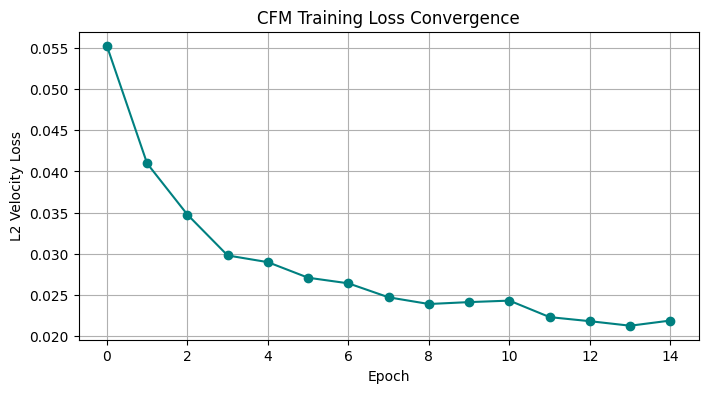

In [4]:
optimizer = torch.optim.AdamW(cfm.parameters(), lr=1e-3)
epochs = 15

print("Starting training loop...")
cfm.train()
losses = []

for epoch in range(1, epochs + 1):
    epoch_loss = 0.0
    n_batches = 0
    for batch in train_loader:
        init_states, target_states, forcing, _ = batch
        
        # Move to device and normalize
        init_states = ((init_states.to(device) - state_mean) / state_std)
        target_states = ((target_states.to(device) - state_mean) / state_std)
        forcing = ((forcing.to(device) - forcing_mean_tiled) / forcing_std_tiled)
        
        loss = cfm.cfm_loss(
            prev_state=init_states[:, 1],
            prev_prev_state=init_states[:, 0],
            forcing=forcing[:, 0],
            target_state=target_states[:, 0],
            mask=interior_mask
        )
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
        
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch:02d}/{epochs:02d} | Train CFM Loss: {avg_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, marker='o', color='teal')
plt.title("CFM Training Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("L2 Velocity Loss")
plt.grid(True)
plt.show()

## Verification and Inline Visualizations
We evaluate the model on the validation split and visualize the $u_{100m}$ predictions inline.

Validation Physical MSE: 5.6610


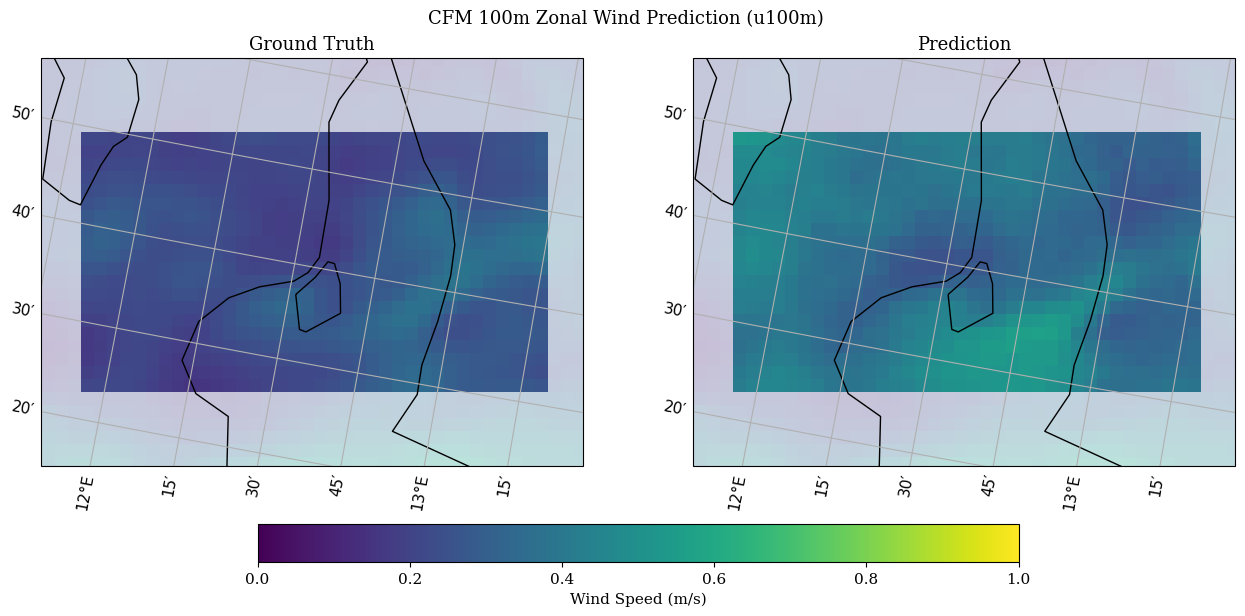

In [5]:
cfm.eval()
val_loss_total = 0.0
val_batches = 0

with torch.no_grad():
    for batch in val_loader:
        init_states, target_states, forcing, target_times = batch
        
        target_raw = target_states.clone()
        
        # Normalize
        init_states_norm = ((init_states.to(device) - state_mean) / state_std)
        forcing_norm = ((forcing.to(device) - forcing_mean_tiled) / forcing_std_tiled)
        
        pred_norm = cfm.sample_step(
            prev_state=init_states_norm[:, 1],
            prev_prev_state=init_states_norm[:, 0],
            forcing=forcing_norm[:, 0],
            n_steps=5
        )
        
        pred_raw = pred_norm * state_std + state_mean
        
        # Overwrite boundary
        pred_raw = (
            boundary_mask.unsqueeze(0).unsqueeze(-1) * target_states.to(device)[:, 0]
            + interior_mask.unsqueeze(0).unsqueeze(-1) * pred_raw
        )
        
        # MSE of interior
        mse = ((pred_raw - target_states.to(device)[:, 0]) ** 2)
        mse_masked = mse[:, interior_mask.to(torch.bool)]
        val_loss_total += mse_masked.mean().item()
        val_batches += 1

print(f"Validation Physical MSE: {val_loss_total / val_batches:.4f}")

# Extract wind speed variable (index 0) for the last validation sample
sample_pred_all = pred_raw[-1].cpu()
sample_target_all = target_raw[-1, 0].cpu()
time_val = pd.to_datetime(target_times[-1, 0].item(), unit="ns")

da_pred_all = train_dataset.create_dataarray_from_tensor(
    tensor=sample_pred_all, time=time_val, category="state"
).unstack("grid_index")

da_target_all = train_dataset.create_dataarray_from_tensor(
    tensor=sample_target_all, time=time_val, category="state"
).unstack("grid_index")

da_pred_u = da_pred_all.isel(state_feature=0)
da_target_u = da_target_all.isel(state_feature=0)

fig = plot_prediction(
    datastore=datastore,
    da_prediction=da_pred_u,
    da_target=da_target_u,
    title="CFM 100m Zonal Wind Prediction (u100m)",
    colorbar_label="Wind Speed (m/s)"
)
plt.show()